# Recreate the Results of the Best Transformer Model
* This notebook recreates the best Transformer model (selected by hyperparameter optimization in `transformer-with-opt.ipynb`) and evaluates it on the test set.

* It is divided into separate cells for imports/configuration, reproducibility and model definition, and reconstruction + evaluation.

## Shared imports and configuration
This cell imports core libraries used throughout the notebook (pandas, numpy, torch, sklearn, etc.),
sets fallback hyperparameters (`FALLBACK_SEQ_LEN`, `FALLBACK_NUM_LAYERS`), and defines file paths for the processed train/test datasets CSVs, the hyperopt results CSV, and the saved model file.
Paths are written relative to the repository root so the notebook can be executed from there.

In [6]:
%pwd
%cd sutd_50039_deep_learning/

/home/sagemaker-user/sutd_50039_deep_learning


In [10]:
# Shared imports and helpers for recreating best-by-Val and best-by-Test models
import pandas as pd
import torch
import os
import numpy as np
import torch.nn as nn
import random
from sklearn.metrics import mean_squared_error
import math

# Configuration fallbacks
FALLBACK_SEQ_LEN = 50
FALLBACK_NUM_LAYERS = 1

# Paths
BASE_FE_DIR = 'data/processed-nasa-data/feature_engineering_2'
TRAIN_FILE = os.path.join(BASE_FE_DIR, 'low_variance_1', 'train_fd001_low_variance_1_125.csv')
TEST_FILE = os.path.join(BASE_FE_DIR, 'low_variance_1', 'test_fd001_low_variance_1_125.csv')
HOPT_CSV = 'hopt_lowvar_results.csv'
MODEL_PATH = 'best_transformer_hopt_lowvar_FINAL.pth'


## Reproducibility, helpers, and model definition
This cell contains:
- Deterministic seeding utilities (`seed_everything`, `seed_worker`) to make runs reproducible across CPU/GPU and DataLoader workers.
- `create_sequences` which converts per-engine time series into sliding-window sequences and corresponding RUL labels.
- A convenience `create_dataloader` wrapper (returns a `DataLoader`).
- The `RULTransformer` model: a Transformer encoder with a learnable positional encoding and a small regressor head.
- `build_and_load` to instantiate the model, load saved weights (handling wrapped `state_dict` and `module.` prefixes), move the model to the correct device, and set it to evaluation mode.

These are all taken from `transformer-with-opt.ipynb` to obtain the exact same result.

In [11]:
# Reproducability Code
def seed_everything(seed=1234):
    os.environ["PYTHONHASHSEED"] = str(seed)
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":16:8"

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    torch.use_deterministic_algorithms(True)

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

def create_sequences(df, feature_cols, seq_len):
    X, y = [], []
    for engine_id, group in df.groupby('id'):
        data = group[feature_cols].values
        labels = group['RUL'].values
        
        # Slide window
        for i in range(len(data) - seq_len + 1):
            X.append(data[i:i + seq_len])
            y.append(labels[i + seq_len - 1])
            
    return np.array(X), np.array(y)

def create_dataloader(X, y, shuffle=True):
    dataset = TensorDataset(torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32))
    return DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=shuffle, worker_init_fn=seed_worker)

# --- MODEL DEFINITION ---
class RULTransformer(nn.Module):
    def __init__(self, input_dim, d_model=64, nhead=4, num_layers=2, dropout=0.1, seq_len=30):
        super(RULTransformer, self).__init__()
        self.input_linear = nn.Linear(input_dim, d_model)
        
        # Initialize positional encoding with a normal distribution (mean=0, std=0.02) and make it a learnable parameter
        self.pos_encoder = nn.Parameter(torch.randn(1, seq_len, d_model) * 0.02)

        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dropout=dropout, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        self.regressor = nn.Sequential(
            nn.Linear(d_model, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )
        
    def forward(self, src):
        # src shape: [batch_size, seq_len, input_dim]
        src = self.input_linear(src) + self.pos_encoder
        output = self.transformer_encoder(src)
        # Take the output of the last time step for sequence classification/regression
        output = output[:, -1, :]
        return self.regressor(output).squeeze(1)

def build_and_load(input_dim, num_layers=2, seq_len=30, model_path=None, d_model=64, nhead=4, dropout=0.1):
    """Build an RULTransformer, load weights if provided, move to device, and return (model, device)."""
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = RULTransformer(input_dim=input_dim, d_model=d_model, nhead=nhead, num_layers=num_layers, dropout=dropout, seq_len=seq_len)
    if model_path is not None and os.path.exists(model_path):
        try:
            state = torch.load(model_path, map_location=device)
            # support both raw state_dict and dicts with 'state_dict' key
            if isinstance(state, dict) and 'state_dict' in state:
                state_dict = state['state_dict']
            else:
                state_dict = state
            # strip any 'module.' prefixes from keys (in case model was saved with DataParallel)
            new_state = {}
            for k, v in state_dict.items():
                new_k = k.replace('module.', '') if k.startswith('module.') else k
                new_state[new_k] = v
            model.load_state_dict(new_state, strict=False)
        except Exception as e:
            print(f"Warning: failed to load model weights from {model_path}: {e}")
    model.to(device)
    model.eval()
    return model, device

## Model reconstruction and evaluation
This cell performs the following steps:
1. Reads `hopt_lowvar_results.csv` to extract the best hyperparameters (sequence length, number of layers, optional learning rate and seed).
2. Optionally sets the global seed if the HOPT row includes a `seed`.
3. Loads test data, constructs sliding-window sequences using `create_sequences`, and prints diagnostic info about the model and torch versions.
4. Builds the `RULTransformer` with `build_and_load`, runs inference on the test set, and computes Test RMSE.
5. If a processed train CSV is available, reconstructs the same train/val split used during tuning, computes train and val RMSEs, and prints the three RMSEs and selected hyperparameters.

In [14]:
# Recreate and evaluate model selected by best Val RMSE
# Read HOPT CSV to get hyperparameters (fall back to defaults if not present)
best_seq_len = FALLBACK_SEQ_LEN
best_num_layers = FALLBACK_NUM_LAYERS
best_lr = None
best_seed = None
if os.path.exists(HOPT_CSV):
    try:
        hopt_df = pd.read_csv(HOPT_CSV)
        if 'seq_len' in hopt_df.columns and 'num_layers' in hopt_df.columns and 'Val RMSE' in hopt_df.columns:
            best_by_val = hopt_df.loc[hopt_df['Val RMSE'].idxmin()]
            best_seq_len = int(best_by_val.get('seq_len', best_seq_len))
            best_num_layers = int(best_by_val.get('num_layers', best_num_layers))
            if 'lr' in hopt_df.columns:
                try:
                    best_lr = float(best_by_val.get('lr', np.nan))
                except Exception:
                    best_lr = None
            if 'seed' in hopt_df.columns:
                try:
                    best_seed = int(best_by_val.get('seed'))
                except Exception:
                    best_seed = None
    except Exception:
        pass

# If training seed is present in HOPT row, set global seeds (note: dataset split uses seed=42 as in transformer-with-opt)
if best_seed is not None:
    seed_everything(best_seed)

# Read test data and prepare sequences
test_df = pd.read_csv(TEST_FILE)
feature_cols = [c for c in test_df.columns if c not in ['id', 'cycle', 'RUL']]
X_test, y_test = create_sequences(test_df, feature_cols, best_seq_len)

# Diagnostics: show which model file and torch versions are used
print(f"Using HOPT row seed={best_seed}, seq_len={best_seq_len}, num_layers={best_num_layers}, lr={best_lr}")
print(f"Loading model from: {MODEL_PATH}")
print(f"torch: {torch.__version__}, cuda: {getattr(torch.version, 'cuda', None)}")

# Build model and run inference using the best-by-Val weights
model, device = build_and_load(input_dim=len(feature_cols), num_layers=best_num_layers, seq_len=best_seq_len, model_path=MODEL_PATH)
with torch.no_grad():
    X_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
    preds = model(X_tensor).cpu().numpy()

# Report test RMSE
test_rmse = math.sqrt(mean_squared_error(y_test, preds))

# Compute train/val RMSE using same split logic as transformer-with-opt.ipynb
train_rmse = None
val_rmse = None
if os.path.exists(TRAIN_FILE):
    try:
        train_full_df = pd.read_csv(TRAIN_FILE)
        all_ids = train_full_df['id'].unique()
        rng = np.random.default_rng(seed=42)
        rng.shuffle(all_ids)
        split = int(len(all_ids) * 0.8)
        train_df = train_full_df[train_full_df['id'].isin(all_ids[:split])].copy()
        val_df = train_full_df[train_full_df['id'].isin(all_ids[split:])].copy()

        X_train, y_train = create_sequences(train_df, feature_cols, best_seq_len)
        X_val, y_val = create_sequences(val_df, feature_cols, best_seq_len)

        with torch.no_grad():
            if len(X_train) > 0:
                train_preds = model(torch.tensor(X_train, dtype=torch.float32).to(device)).cpu().numpy()
                train_rmse = math.sqrt(mean_squared_error(y_train, train_preds))
            if len(X_val) > 0:
                val_preds = model(torch.tensor(X_val, dtype=torch.float32).to(device)).cpu().numpy()
                val_rmse = math.sqrt(mean_squared_error(y_val, val_preds))
    except Exception:
        pass

# Print only hyperparameters and the three RMSEs
print(f"seed={best_seed}, seq_len={best_seq_len}, num_layers={best_num_layers}, lr={best_lr}")
print(f"Train RMSE: {train_rmse:.4f}" if train_rmse is not None else "Train RMSE: N/A")
print(f"Val RMSE: {val_rmse:.4f}" if val_rmse is not None else "Val RMSE: N/A")
print(f"Test RMSE: {test_rmse:.4f}")

Using HOPT row seed=None, seq_len=50, num_layers=1, lr=None
Loading model from: Transformer/best_transformer_hopt_lowvar_FINAL.pth
torch: 2.6.0, cuda: 12.6
seed=None, seq_len=50, num_layers=1, lr=None
Train RMSE: 8.2568
Val RMSE: 10.8808
Test RMSE: 12.4161


Classification task using device: cuda

Test data features available: 17
Features to process:
   1. setting1
   2. setting2
   3. s2
   4. s3
   5. s4
   6. s6
   7. s7
   8. s8
   9. s9
  10. s11
  11. s12
  12. s13
  13. s14
  14. s15
  15. s17
  16. s20
  17. s21

Loading checkpoint from: Transformer/best_transformer_hopt_lowvar_FINAL.pth
Model checkpoint expects 17 features
✓ Feature dimensions match! (17 == 17)

Creating RULTransformer with input_dim=17
Transformer model loaded successfully

Running inference on 100 engines with shape (100, 50, 17)...

CLASSIFICATION RESULTS
Accuracy:  0.9400
Precision: 0.9524
Recall:    0.8000
F1-Score:  0.8696

Confusion Matrix:
  True Negatives (Healthy, predicted Healthy):    74
  False Positives (Healthy, predicted Not Healthy): 1
  False Negatives (Not Healthy, predicted Healthy): 5
  True Positives (Not Healthy, predicted Not Healthy): 20


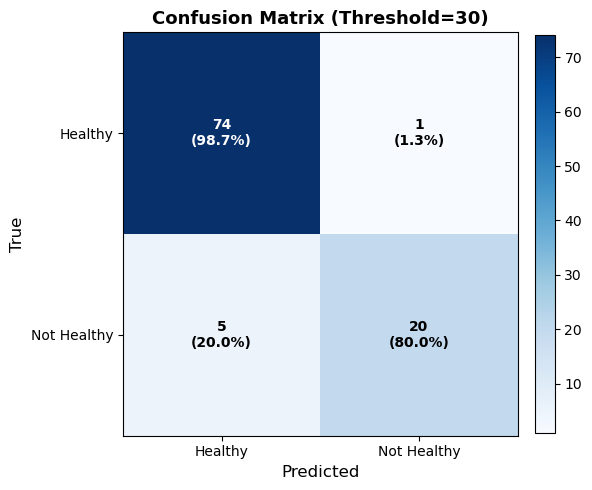


First 10 results:
   id  predicted_rul  true_rul predicted_state true_state
0   1      61.737045       112         Healthy    Healthy
1   2     114.740860        98         Healthy    Healthy
2   3      69.598358        69         Healthy    Healthy
3   4      93.539040        82         Healthy    Healthy
4   5     101.725731        91         Healthy    Healthy
5   6     116.073456        93         Healthy    Healthy
6   7      99.428032        91         Healthy    Healthy
7   8      73.453804        95         Healthy    Healthy
8   9     109.860855       111         Healthy    Healthy
9  10      71.023941        96         Healthy    Healthy


In [18]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Configuration
MODEL_PATH_TRANSFORMER = "Transformer/best_transformer_hopt_lowvar_FINAL.pth"
TEST_CSV_PATH = "data/processed-nasa-data/feature_engineering_2/low_variance_1/test_fd001_low_variance_1_125.csv"
THRESHOLD = 30

DEVICE_CLS = torch.device(
    "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
)
print(f"Classification task using device: {DEVICE_CLS}")

# Load test data
test_df_cls = pd.read_csv(TEST_CSV_PATH)

# ✓ FIXED: Include setting1, setting2 AND all sensors (17 total features)
test_feature_cols = [col for col in test_df_cls.columns if col not in ['id', 'cycle', 'RUL']]
test_num_features = len(test_feature_cols)

print(f"\nTest data features available: {test_num_features}")
print("Features to process:")
for i, col in enumerate(test_feature_cols, 1):
    print(f"  {i:2d}. {col}")
print()

# Load checkpoint to infer correct input_dim
print(f"Loading checkpoint from: {MODEL_PATH_TRANSFORMER}")
state_cls = torch.load(MODEL_PATH_TRANSFORMER, map_location=DEVICE_CLS)

# Handle wrapped state dict
if isinstance(state_cls, dict) and 'state_dict' in state_cls:
    state_dict_cls = state_cls['state_dict']
else:
    state_dict_cls = state_cls

# Infer input_dim from the saved checkpoint
saved_input_linear_weight = None
for k, v in state_dict_cls.items():
    if 'input_linear.weight' in k or 'input_linear.weight' in k.replace('module.', ''):
        saved_input_linear_weight = v
        break

if saved_input_linear_weight is not None:
    saved_input_dim = saved_input_linear_weight.shape[1]
    print(f"Model checkpoint expects {saved_input_dim} features")
else:
    saved_input_dim = test_num_features
    print(f"Could not infer input_dim from checkpoint, using test data: {saved_input_dim}")

# Verify dimensions match
if saved_input_dim == test_num_features:
    print(f"✓ Feature dimensions match! ({saved_input_dim} == {test_num_features})\n")
else:
    print(f"⚠ Feature dimension mismatch: model={saved_input_dim}, test data={test_num_features}\n")

# Load the best transformer model with correct input dimension
print(f"Creating RULTransformer with input_dim={saved_input_dim}")
model_transformer = RULTransformer(
    input_dim=saved_input_dim,
    d_model=64,
    nhead=4,
    num_layers=best_num_layers,
    dropout=0.1,
    seq_len=best_seq_len
).to(DEVICE_CLS)

# Strip 'module.' prefix if present
new_state_cls = {}
for k, v in state_dict_cls.items():
    new_k = k.replace('module.', '') if k.startswith('module.') else k
    new_state_cls[new_k] = v

model_transformer.load_state_dict(new_state_cls, strict=False)
model_transformer.eval()
print("Transformer model loaded successfully\n")

# ✓ SIMPLIFIED: Prepare sequences using all 17 features (settings + sensors)
engine_ids_cls = []
x_last_cls = []
for engine_id, group in test_df_cls.groupby("id"):
    group_sorted = group.sort_values("cycle")
    
    # Extract all features in correct order
    seq = group_sorted[test_feature_cols].values.astype(np.float32)
    
    # Pad sequences shorter than best_seq_len
    if len(seq) < best_seq_len:
        pad_len = best_seq_len - len(seq)
        pad = np.zeros((pad_len, seq.shape[1]), dtype=seq.dtype)
        seq = np.vstack([pad, seq])
    else:
        seq = seq[-best_seq_len:]
    
    x_last_cls.append(seq)
    engine_ids_cls.append(engine_id)

x_last_cls = np.array(x_last_cls, dtype=np.float32)
x_tensor_cls = torch.tensor(x_last_cls, dtype=torch.float32).to(DEVICE_CLS)

print(f"Running inference on {len(engine_ids_cls)} engines with shape {x_last_cls.shape}...")
with torch.no_grad():
    preds_cls = model_transformer(x_tensor_cls).cpu().numpy()

# Create results dataframe
results_cls = pd.DataFrame({
    "id": engine_ids_cls,
    "predicted_rul": preds_cls.flatten(),
})

# Get ground truth RUL from test data (last RUL value per engine)
ground_truth_rul = test_df_cls.groupby("id")["RUL"].last().reindex(results_cls["id"]).values

# Binary classification: RUL <= THRESHOLD = "Not Healthy" (1), else "Healthy" (0)
results_cls["true_rul"] = ground_truth_rul
results_cls["predicted_health"] = np.where(results_cls["predicted_rul"] <= THRESHOLD, 1, 0)
results_cls["true_health"] = np.where(results_cls["true_rul"] <= THRESHOLD, 1, 0)
results_cls["predicted_state"] = np.where(results_cls["predicted_rul"] <= THRESHOLD, "Not Healthy", "Healthy")
results_cls["true_state"] = np.where(results_cls["true_rul"] <= THRESHOLD, "Not Healthy", "Healthy")

print("\n" + "="*80)
print("CLASSIFICATION RESULTS")
print("="*80)

# Classification metrics
y_true = results_cls["true_health"].values
y_pred = results_cls["predicted_health"].values

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, zero_division=0)
rec = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)
cm = confusion_matrix(y_true, y_pred)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-Score:  {f1:.4f}")
print("\nConfusion Matrix:")
print(f"  True Negatives (Healthy, predicted Healthy):    {cm[0, 0]}")
print(f"  False Positives (Healthy, predicted Not Healthy): {cm[0, 1]}")
print(f"  False Negatives (Not Healthy, predicted Healthy): {cm[1, 0]}")
print(f"  True Positives (Not Healthy, predicted Not Healthy): {cm[1, 1]}")

# Plot confusion matrix
labels = ["Healthy", "Not Healthy"]
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues", aspect='auto')
ax.set_title(f"Confusion Matrix (Threshold={THRESHOLD})", fontsize=13, fontweight='bold')
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("True", fontsize=12)
ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)

# Add counts and percentages in each cell
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        count = cm[i, j]
        total = cm[i, :].sum()
        percentage = (count / total * 100) if total > 0 else 0
        text = ax.text(j, i, f"{count}\n({percentage:.1f}%)",
                      ha="center", va="center", color="white" if count > cm.max() / 2 else "black",
                      fontweight='bold')

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

print("\nFirst 10 results:")
print(results_cls[["id", "predicted_rul", "true_rul", "predicted_state", "true_state"]].head(10))